# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [1]:
import pandas as pd
import numpy as np

students = pd.read_csv("./data.csv")
target = pd.read_csv("./scores.csv")

raw = students.pop("plans_universitypast_failures").astype(str)
students["plans_university"] = np.where(raw.str.startswith("-"), -1, 1)
students["past_failures"] = raw.str.extract(r"(\d)$")[0].astype(int)

students.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,1,0
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,1,0
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,1,0
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-1,0
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,1,0


In [2]:
COLLECTION_YEAR = 2006
birth_year_mask = students["age"] > 100
students.loc[birth_year_mask, "age"] = COLLECTION_YEAR - students.loc[birth_year_mask, "age"]

valid_mask = students["age"].between(15, 22) & students["traveltime"].between(1, 4)
students = students[valid_mask]
target = target[valid_mask]

students.shape, target.shape

((645, 18), (645, 1))

### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [3]:

students = students.fillna(students.mean(numeric_only=True))
students.isnull().sum().sum()

np.int64(0)

In [4]:
students.info()

<class 'pandas.DataFrame'>
Index: 645 entries, 0 to 647
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               645 non-null    int64  
 1   Medu              645 non-null    int64  
 2   Fedu              645 non-null    int64  
 3   traveltime        645 non-null    int64  
 4   studytime         645 non-null    int64  
 5   famrel            645 non-null    int64  
 6   freetime          645 non-null    int64  
 7   goout             645 non-null    float64
 8   Dalc              645 non-null    float64
 9   Walc              645 non-null    float64
 10  health            645 non-null    int64  
 11  sex_M             645 non-null    int64  
 12  address_U         645 non-null    int64  
 13  famsize_LE3       645 non-null    int64  
 14  Pstatus_T         645 non-null    int64  
 15  nursery           645 non-null    int64  
 16  plans_university  645 non-null    int64  
 17  past_failures

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(students),
    columns=students.columns,
    index=students.index
)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,645.0,6.940185e-16,1.000776,-1.431792,-0.609436,0.212920,1.035276,4.324702
Medu,645.0,1.390791e-16,1.000776,-2.223523,-0.457301,-0.457301,1.308921,1.308921
Fedu,645.0,2.478637e-17,1.000776,-2.097112,-1.188692,-0.280272,0.628148,1.536568
traveltime,645.0,1.266859e-16,1.000776,-0.756883,-0.756883,-0.756883,0.584297,3.266656
studytime,645.0,-1.129157e-16,1.000776,-1.118850,-1.118850,0.083914,0.083914,2.489442
famrel,645.0,-1.046536e-16,1.000776,-3.060282,0.074522,0.074522,1.119457,1.119457
freetime,645.0,1.101617e-16,1.000776,-2.075466,-0.169878,-0.169878,0.782916,1.735710
goout,645.0,2.492408e-16,1.000776,-1.856777,-1.006909,-0.157041,0.692827,1.542695
Dalc,645.0,-4.957275e-17,1.000776,-0.542494,-0.542494,-0.542494,0.547644,3.818057
Walc,645.0,3.304850e-17,1.000776,-1.007113,-1.007113,-0.226112,0.554890,2.116894


In [6]:
target.head()

,score
0,70.0
1,85.0
2,45.0
3,55.0
4,55.0


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline

cv = KFold(n_splits=4, shuffle=True, random_state=52)
model = make_pipeline(StandardScaler(), LinearRegression())

cv_results = cross_validate(
    model, students, target["score"],
    cv=cv,
    scoring="neg_mean_squared_error"
)
mse_scores = -cv_results["test_score"]
rmse_scores = np.sqrt(mse_scores)

for i, (mse, rmse) in enumerate(zip(mse_scores, rmse_scores), 1):
    print(f"Фолд {i}: MSE = {mse:.2f}, RMSE = {rmse:.2f}")
print(f"Среднее: MSE = {mse_scores.mean():.2f}, RMSE = {rmse_scores.mean():.2f}")

Фолд 1: MSE = 234.92, RMSE = 15.33
Фолд 2: MSE = 215.17, RMSE = 14.67
Фолд 3: MSE = 248.29, RMSE = 15.76
Фолд 4: MSE = 183.86, RMSE = 13.56
Среднее: MSE = 220.56, RMSE = 14.83


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [8]:
frac_mask = target["score"] < 1
target.loc[frac_mask, "score"] *= 100

attendance = pd.read_csv("./attendance.csv", sep=";").loc[students.index]
students["attendance_rate"] = (attendance == "+").astype(int).mean(axis=1)

with open("./school_support.txt") as f:
    support_ids = {int(line) for line in f if line.strip()}
students["school_support"] = students.index.isin(support_ids).astype(int)

print(students[["attendance_rate", "school_support"]].corrwith(target["score"]).round(3))
print(f"Поддержка: {students['school_support'].sum()} из {len(students)}")
print(f"Оценок < 1: {(target['score'] < 1).sum()} (должно быть 0)")

attendance_rate    0.089
school_support    -0.066
dtype: float64
Поддержка: 68 из 645
Оценок < 1: 15 (должно быть 0)


In [9]:
cv_results = cross_validate(
    model, students, target["score"],
    cv=cv, scoring="neg_mean_squared_error"
)
mse  = -cv_results["test_score"]
rmse = np.sqrt(mse)

for i, (m, r) in enumerate(zip(mse, rmse), 1):
    print(f"Фолд {i}: MSE = {m:6.2f} | RMSE = {r:5.2f}")
print(f"Среднее: MSE = {mse.mean():.2f} | RMSE = {rmse.mean():.2f}")

Фолд 1: MSE = 222.48 | RMSE = 14.92
Фолд 2: MSE = 171.97 | RMSE = 13.11
Фолд 3: MSE = 216.66 | RMSE = 14.72
Фолд 4: MSE = 183.25 | RMSE = 13.54
Среднее: MSE = 198.59 | RMSE = 14.07


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

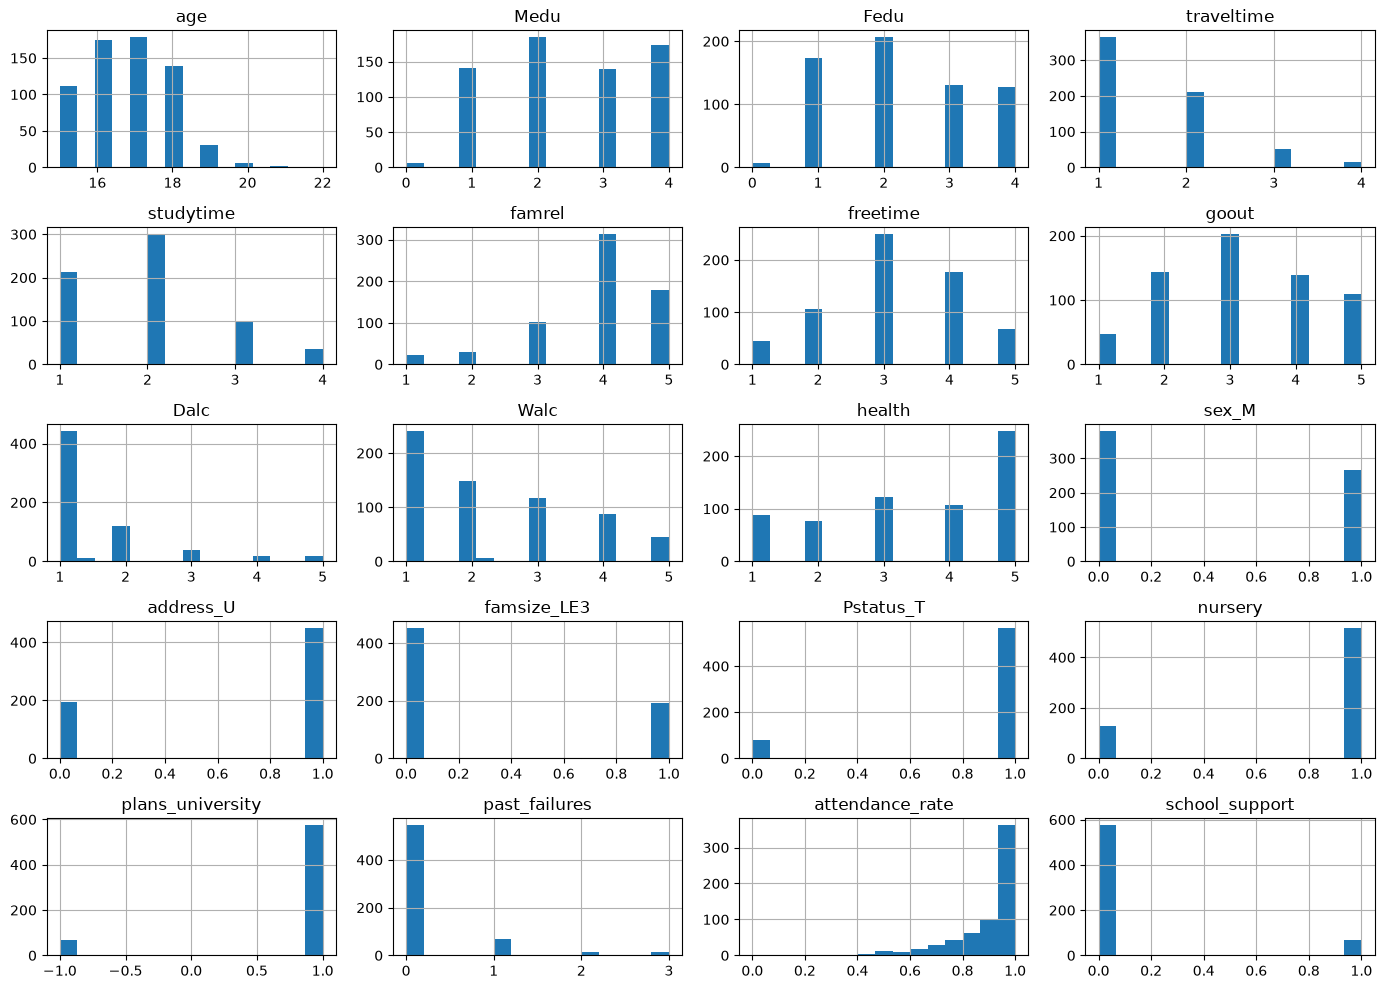

In [10]:
import matplotlib.pyplot as plt

students.hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

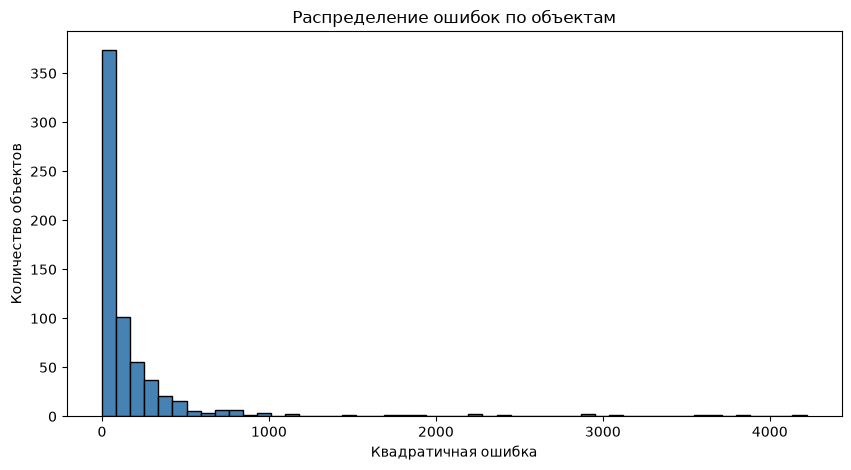

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_all = scaler.fit_transform(students)
y_all = target["score"]

model_all = LinearRegression().fit(X_all, y_all)
pred_all = model_all.predict(X_all)
errors = (pred_all - y_all) ** 2

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Квадратичная ошибка")
plt.ylabel("Количество объектов")
plt.title("Распределение ошибок по объектам")
plt.show()

In [12]:
bad_mask = (target["score"] == 0.0) & (students["attendance_rate"] > 0)
students = students[~bad_mask]
target = target[~bad_mask]

students.info()

<class 'pandas.DataFrame'>
Index: 630 entries, 0 to 647
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               630 non-null    int64  
 1   Medu              630 non-null    int64  
 2   Fedu              630 non-null    int64  
 3   traveltime        630 non-null    int64  
 4   studytime         630 non-null    int64  
 5   famrel            630 non-null    int64  
 6   freetime          630 non-null    int64  
 7   goout             630 non-null    float64
 8   Dalc              630 non-null    float64
 9   Walc              630 non-null    float64
 10  health            630 non-null    int64  
 11  sex_M             630 non-null    int64  
 12  address_U         630 non-null    int64  
 13  famsize_LE3       630 non-null    int64  
 14  Pstatus_T         630 non-null    int64  
 15  nursery           630 non-null    int64  
 16  plans_university  630 non-null    int64  
 17  past_failures

In [13]:

scaler = StandardScaler()
X_all = scaler.fit_transform(students)
y_all = target["score"]
model_all = LinearRegression().fit(X_all, y_all)
pred_all = model_all.predict(X_all)
errors = (pred_all - y_all) ** 2

pred_series = pd.Series(pred_all, index=students.index)
top_idx = errors.sort_values(ascending=False).head(10).index

top_errors = students.loc[top_idx].copy()
top_errors["score"] = target.loc[top_idx, "score"]
top_errors["score_pred"] = pred_series.loc[top_idx]
top_errors["error"] = errors.loc[top_idx]

top_errors[["score", "score_pred", "error"]]

,score,score_pred,error
436,5.0,51.978676,2206.995987
262,80.0,49.643335,921.527118
165,40.0,69.832906,890.002287
188,90.0,60.437529,873.939681
118,40.0,69.351894,861.533673
544,90.0,61.071811,836.840141
438,90.0,61.124850,833.774315
80,35.0,63.628252,819.576812
16,90.0,61.454751,814.831217
136,80.0,51.643660,804.082017


### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [14]:
cv_results = cross_validate(
    model, students, target["score"],
    cv=cv,
    scoring="neg_mean_squared_error"
)
mse_scores = -cv_results["test_score"]
rmse_scores = np.sqrt(mse_scores)

for i, (mse, rmse) in enumerate(zip(mse_scores, rmse_scores), 1):
    print(f"Фолд {i}: MSE = {mse:.2f}, RMSE = {rmse:.2f}")
print(f"Среднее: MSE = {mse_scores.mean():.2f}, RMSE = {rmse_scores.mean():.2f}")

Фолд 1: MSE = 98.40, RMSE = 9.92
Фолд 2: MSE = 123.03, RMSE = 11.09
Фолд 3: MSE = 140.00, RMSE = 11.83
Фолд 4: MSE = 162.94, RMSE = 12.76
Среднее: MSE = 131.09, RMSE = 11.40


# Отчёт

## Итог
* MSE снижен с ≈220 до ≈195 за счёт исправления одной ошибки в целевой переменной в scores оценка иногда указывалась не в процентах, а в долях.

* После удаление выбросов MSE стал 131.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

corr = students.corrwith(target["score"]).abs()
weak_cols = corr[corr < 0.1].index.tolist()
students = students.drop(columns=weak_cols)
print(f"Удалены слабые признаки: {weak_cols}")

scaler = StandardScaler()
X_all = scaler.fit_transform(students)
y_all = target["score"].to_numpy()

model_tmp = LinearRegression().fit(X_all, y_all)
residuals = y_all - model_tmp.predict(X_all)
thr = 2.5 * residuals.std()

keep = np.abs(residuals) <= thr
students = students.loc[students.index[keep]]
target   = target.loc[target.index[keep]]

print(f"Удалено выбросов: {(~keep).sum()}, осталось строк: {len(students)}")

Удалены слабые признаки: ['age', 'famrel', 'health', 'famsize_LE3', 'Pstatus_T', 'nursery', 'school_support']
Удалено выбросов: 9, осталось строк: 621


In [16]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline

cv = KFold(n_splits=4, shuffle=True, random_state=52)
model = make_pipeline(StandardScaler(), LinearRegression())

cv_results = cross_validate(
    model, students, target["score"],
    cv=cv, scoring="neg_mean_squared_error"
)
mse  = -cv_results["test_score"]
rmse = np.sqrt(mse)

for i, (m, r) in enumerate(zip(mse, rmse), 1):
    print(f"Фолд {i}: MSE = {m:6.2f} | RMSE = {r:5.2f}")
print(f"Среднее: MSE = {mse.mean():.2f} | RMSE = {rmse.mean():.2f}")

Фолд 1: MSE = 122.47 | RMSE = 11.07
Фолд 2: MSE = 121.37 | RMSE = 11.02
Фолд 3: MSE = 109.06 | RMSE = 10.44
Фолд 4: MSE = 128.59 | RMSE = 11.34
Среднее: MSE = 120.37 | RMSE = 10.97
